# DATA MODELS

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from matplotlib.patches import Patch
import matplotlib.patches as mpatches
from scipy.stats import chi2_contingency, f_oneway
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder
from sklearn.decomposition import PCA

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.metrics import (accuracy_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay,
    roc_auc_score, roc_curve)

#Importing for SVM Models
from sklearn.svm import SVC

import warnings
warnings.filterwarnings('ignore')
from sklearn.compose import ColumnTransformer

#Importing for RandomForest Models
from sklearn.ensemble import RandomForestClassifier
from sklearn.compose import ColumnTransformer

#Importing for Logistic Regression Models
from sklearn.linear_model import LogisticRegression


In [3]:
pip install ucimlrepo

Note: you may need to restart the kernel to use updated packages.


In [4]:
from ucimlrepo import fetch_ucirepo 
  
# fetch dataset 
df_adult = fetch_ucirepo(id=2) 
  
# data (as pandas dataframes) 
X = df_adult.data.features 
Y = df_adult.data.targets 

# Merging features and target table(X and Y)
df_adult = X.copy()
df_adult["income"] = Y.iloc[:, 0] 

In [5]:
df_adult.describe()

,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week
count,48842.000000,4.884200e+04,48842.000000,48842.000000,48842.000000,48842.000000
mean,38.643585,1.896641e+05,10.078089,1079.067626,87.502314,40.422382
std,13.710510,1.056040e+05,2.570973,7452.019058,403.004552,12.391444
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.175505e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.781445e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.376420e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.490400e+06,16.000000,99999.000000,4356.000000,99.000000


In [6]:
df_adult.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             48842 non-null  int64 
 1   workclass       47879 non-null  object
 2   fnlwgt          48842 non-null  int64 
 3   education       48842 non-null  object
 4   education-num   48842 non-null  int64 
 5   marital-status  48842 non-null  object
 6   occupation      47876 non-null  object
 7   relationship    48842 non-null  object
 8   race            48842 non-null  object
 9   sex             48842 non-null  object
 10  capital-gain    48842 non-null  int64 
 11  capital-loss    48842 non-null  int64 
 12  hours-per-week  48842 non-null  int64 
 13  native-country  48568 non-null  object
 14  income          48842 non-null  object
dtypes: int64(6), object(9)
memory usage: 5.6+ MB


In [7]:
df_adult.shape

(48842, 15)

In [8]:
df_adult.sample()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
35362,46,State-gov,121586,Bachelors,13,Married-civ-spouse,Craft-repair,Husband,White,Male,0,0,40,United-States,<=50K.


In [9]:
df_adult["income_binary"] = (df_adult["income"] == ">50K").astype(int)
# Removing the trailing dot for income column
df_adult["income"] = df_adult["income"].str.strip().str.replace(".", "", regex=False)


In [10]:

df_adult['age_bin'] = pd.cut(df_adult['age'],
    bins=[0, 25, 35, 50, 65, 100],
    labels=['Young (≤25)', 'Early Career (26–35)', 'Mid Career (36–50)',
            'Late Career (51–65)', 'Senior (65+)'])

# Age group — based on your pair plot findings
df_adult["age_group"] = pd.cut(df_adult["age"],
                          bins=[0, 30, 45, 60, 100],
                          labels=["Young", "Middle", "Senior", "Elderly"])

In [11]:
df_adult['education_group'] = pd.cut(
    df_adult['education-num'],
    bins=[0, 9, 13, 16],
    labels=['Low Education', 'Undergrad Level', 'Graduate Level']
)

# define mapping dictionaries--workclass
workclass_group= {'Never-worked' :'Without-pay', 'Without-pay' : 'Without-pay',
                  'Local-gov':'gov','State-gov':'gov','Federal-gov' : 'Federal-gov',
                  'Self-emp-not-inc' : 'Private', 'Private':'Private',
                 'Self-emp-inc' : 'Self-emp-inc'}
#apply replacements
df_adult['workclass']=df_adult['workclass'].map(workclass_group).fillna('Other')


# define mapping dictionaries--maritalstatus_group

maritalstatus_group={'Divorced' :'No-spouse', 'Separated':'No-spouse','Widowed':'No-spouse',
                     'Married-spouse-absent':'No-spouse','Married-AF-spouse':'No-spouse',
                     'Married-civ-spouse':'Married-civ-spouse', 'Never-married':'Never-married'}
#apply replacements
df_adult['marital-status']=df_adult['marital-status'].map(maritalstatus_group).fillna('Other')


relationship_map = {
    # Married
    "Husband"        : "Married",
    "Wife"           : "Married",
    # Family
    "Own-child"      : "Family",
    "Other-relative" : "Family",
    # Alone
    "Not-in-family"  : "Alone",
    "Unmarried"      : "Alone"
}

# Apply mapping
df_adult["relationship"] = df_adult["relationship"].map(relationship_map)


# define mapping dictionaries-- occupation_group

# Group 15 occupation categories into 5 meaningful groups
occupation_map = {
    # White Collar — professional/office jobs
    "Exec-managerial"  : "White_Collar",
    "Prof-specialty"   : "White_Collar",
    "Adm-clerical"     : "White_Collar",
    "Tech-support"     : "White_Collar",
    # Blue Collar — manual/trade jobs
    "Craft-repair"     : "Blue_Collar",
    "Machine-op-inspct": "Blue_Collar",
    "Transport-moving" : "Blue_Collar",
    "Handlers-cleaners": "Blue_Collar",
    "Farming-fishing"  : "Blue_Collar",
    # Service — customer/service jobs
    "Other-service"    : "Service",
    "Protective-serv"  : "Service",
    "Priv-house-serv"  : "Service",
    # Sales
    "Sales"            : "Sales",
    # Armed Forces
    "Armed-Forces"     : "Armed_Forces"
}

# Apply mapping
df_adult["occupation"] = df_adult["occupation"].map(occupation_map)



In [12]:
# Create bins for hours-per-week
df_adult['hours_bin'] = pd.cut(df_adult['hours-per-week'],bins=[0, 25, 40, 50, 60, 100],labels=['<25', '25-40', '41-50', '51-60', '60+'])

In [13]:
# filling the values replace  ‘?’ is ‘Workclass’ column by ‘Private’, ‘Occupation’ column by ‘Prof-speciality’ 
#and ‘Native_country’by ‘United_States’. (MODE VALUES)

m = df_adult['workclass'].mode()[0]
o = df_adult['occupation'].mode()[0]
n = df_adult['native-country'].mode()[0]

df_adult['workclass'] = df_adult['workclass'].replace('?', m)
df_adult['occupation'] = df_adult['occupation'].replace('?', o)       # was using n instead of o
df_adult['native-country'] = df_adult['native-country'].replace('?', n)  # missing closing )

In [14]:
from scipy.stats import chi2_contingency

# Step 1: Bin numerical features
df_chi = df_adult.copy()
df_chi["age_bin"]            = pd.cut(df_chi["age"],            bins=5)
df_chi["fnlwgt_bin"]         = pd.cut(df_chi["fnlwgt"],         bins=5)
df_chi["education_num_bin"]  = pd.cut(df_chi["education-num"],  bins=5)
df_chi["capital_gain_bin"]   = pd.cut(df_chi["capital-gain"],   bins=5)
df_chi["capital_loss_bin"]   = pd.cut(df_chi["capital-loss"],   bins=5)
df_chi["hours_week_bin"]     = pd.cut(df_chi["hours-per-week"], bins=5)

# Step 2: Define all features
all_features = {
    "workclass"              : "workclass",
    "education"              : "education",
    "marital-status"         : "marital-status",
    "occupation"             : "occupation",
    "relationship"           : "relationship",
    "race"                   : "race",
    "sex"                    : "sex",
    "native-country"         : "native-country",
    "age (binned)"           : "age_bin",
    "fnlwgt (binned)"        : "fnlwgt_bin",
    "education-num (binned)" : "education_num_bin",
    "capital-gain (binned)"  : "capital_gain_bin",
    "capital-loss (binned)"  : "capital_loss_bin",
    "hours-per-week (binned)": "hours_week_bin",
}

# Step 3: Run Chi-Square
chi2_results = []
for label, col in all_features.items():
    ct = pd.crosstab(df_chi[col], df_chi["income"])
    chi2, p, dof, _ = chi2_contingency(ct)
    chi2_results.append({
        "Feature"    : label,
        "Chi2"       : round(chi2, 2),
        "p-value"    : p,
        "DOF"        : dof,
        "Type"       : "Numerical" if "(binned)" in label else "Categorical",
        "Significant": "Yes" if p < 0.05 else "No"
    })

chi2_df = pd.DataFrame(chi2_results).sort_values("Chi2", ascending=False)

# Step 4: Styled Table only
def highlight_rows(row):
    if row["Significant"] == "Yes" and row["Type"] == "Categorical":
        return ["background-color: #d4e6f1"] * len(row)
    elif row["Significant"] == "Yes" and row["Type"] == "Numerical":
        return ["background-color: #d5f5e3"] * len(row)
    else:
        return ["background-color: #fadbd8"] * len(row)

chi2_df[["Feature", "Chi2", "p-value", "Type", "Significant"]]\
    .style\
    .apply(highlight_rows, axis=1)\
    .format({"Chi2": "{:,.2f}", "p-value": "{:.2e}"})\
    .set_caption("Chi-Square Test — All Features vs Income")\
    .hide(axis="index")

Feature,Chi2,p-value,Type,Significant
relationship,"10,047.49",0.00e+00,Categorical,Yes
marital-status,"9,789.71",0.00e+00,Categorical,Yes
education,"6,537.97",0.00e+00,Categorical,Yes
education-num (binned),"5,949.74",0.00e+00,Numerical,Yes
age (binned),"4,273.64",0.00e+00,Numerical,Yes
hours-per-week (binned),"3,206.44",0.00e+00,Numerical,Yes
occupation,"2,613.95",0.00e+00,Categorical,Yes
sex,"2,248.85",0.00e+00,Categorical,Yes
capital-loss (binned),"1,864.53",0.00e+00,Numerical,Yes
workclass,"1,534.28",0.00e+00,Categorical,Yes


## Feature Engineering

In [15]:
# Drop based on our analysis findings
df_adult.drop(columns=["fnlwgt", "native-country", "race"], inplace=True)


In [16]:
# Encode Target Variable
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

# Binary encode income (<=50K = 0, >50K = 1)
df_adult["income"] = le.fit_transform(df_adult["income"])

# Binary encode sex (Male = 1, Female = 0)
df_adult["sex"] = le.fit_transform(df_adult["sex"])

In [17]:
#  Capital Feature Engineering 

# Create net capital = gain - loss
df_adult["net_capital"] = df_adult["capital-gain"] - df_adult["capital-loss"]

# Log transform net capital — clip negatives to 0 before applying log
df_adult["log_net_capital"] = np.log1p(df_adult["net_capital"].clip(lower=0))

# Drop original columns — replaced by log transformed versions
df_adult.drop(columns=["capital-gain", "capital-loss", "net_capital"], inplace=True)

In [18]:
# One-hot encode nominal categorical columns
df_encoded = pd.get_dummies(df_adult, columns=["workclass", "education_group", "marital-status", 
                                             "occupation", "relationship", "age_group","hours_bin"], drop_first=True)

In [19]:
df_encoded.head()

,age,education,education-num,sex,hours-per-week,income,income_binary,age_bin,log_net_capital,workclass_Other,...,occupation_White_Collar,relationship_Family,relationship_Married,age_group_Middle,age_group_Senior,age_group_Elderly,hours_bin_25-40,hours_bin_41-50,hours_bin_51-60,hours_bin_60+
0,39,Bachelors,13,1,40,0,0,Mid Career (36–50),7.684784,False,...,True,False,False,True,False,False,True,False,False,False
1,50,Bachelors,13,1,13,0,0,Mid Career (36–50),0.000000,False,...,True,False,True,False,True,False,False,False,False,False
2,38,HS-grad,9,1,40,0,0,Mid Career (36–50),0.000000,False,...,False,False,False,True,False,False,True,False,False,False
3,53,11th,7,1,40,0,0,Late Career (51–65),0.000000,False,...,False,False,True,False,True,False,True,False,False,False
4,28,Bachelors,13,0,40,0,0,Early Career (26–35),0.000000,False,...,True,False,True,False,False,False,True,False,False,False


In [20]:
# Convert all bool columns to int
bool_cols = df_encoded.select_dtypes(include='bool').columns
df_encoded[bool_cols] = df_encoded[bool_cols].astype(int)

In [21]:
df_encoded.drop(columns=["age", "education-num", "education","age_bin", "hours-per-week","income_binary"], inplace=True)


In [22]:
df_encoded.head(5)

,sex,income,log_net_capital,workclass_Other,workclass_Private,workclass_Self-emp-inc,workclass_Without-pay,workclass_gov,education_group_Undergrad Level,education_group_Graduate Level,...,occupation_White_Collar,relationship_Family,relationship_Married,age_group_Middle,age_group_Senior,age_group_Elderly,hours_bin_25-40,hours_bin_41-50,hours_bin_51-60,hours_bin_60+
0,1,0,7.684784,0,0,0,0,1,1,0,...,1,0,0,1,0,0,1,0,0,0
1,1,0,0.000000,0,1,0,0,0,1,0,...,1,0,1,0,1,0,0,0,0,0
2,1,0,0.000000,0,1,0,0,0,0,0,...,0,0,0,1,0,0,1,0,0,0
3,1,0,0.000000,0,1,0,0,0,0,0,...,0,0,1,0,1,0,1,0,0,0
4,0,0,0.000000,0,1,0,0,0,1,0,...,1,0,1,0,0,0,1,0,0,0


# Models

# SVM

In [23]:
# ============================================================
# SVM — Adult Income Dataset
# ============================================================
# ── Define X and y ─────────────────────────────────────
# income is already 0/1 integer — no mapping needed
y = df_encoded['income']
X = df_encoded.drop(columns=['income'])

print("Class distribution:")
print(y.value_counts())  # Should show both 0 and 1 now

# ── 1. Identify remaining string columns ──────────────────
# Some columns like 'education', 'race', 'sex', 'native_country'
# may NOT have been encoded yet
cat_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()
num_cols = X.select_dtypes(exclude=['object', 'category']).columns.tolist()

print(f"\nRemaining categorical cols: {cat_cols}")
print(f"Numerical cols count: {len(num_cols)}")

# ── 2. Train / Test Split ──────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"\nTrain: {len(X_train):,}  |  Test: {len(X_test):,}")

# ── 3. Sample 20% for speed ───────────────────────────────
sample_idx = X_train.sample(frac=0.2, random_state=42).index
X_train_s  = X_train.loc[sample_idx]
y_train_s  = y_train.loc[sample_idx]
print(f"Training SVM on {len(X_train_s):,} samples")

# ── 4. Build pipeline (handles any leftover string cols) ───

if cat_cols:
    # Still has string columns — encode them
    preprocessor = ColumnTransformer(transformers=[
        ('num', StandardScaler(), num_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_cols)
    ])
else:
    # Fully numeric — just scale
    preprocessor = StandardScaler()

svm_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', SVC(
        kernel      = 'rbf',
        C           = 1.0,
        gamma       = 'scale',
        probability = True,
        random_state= 42
    ))
])

svm_pipeline.fit(X_train_s, y_train_s)
print("\n✅ Model trained successfully")

# ── 5. Predictions ─────────────────────────────────────────
y_pred = svm_pipeline.predict(X_test)
y_prob = svm_pipeline.predict_proba(X_test)[:, 1]

# ── 6. Evaluation Metrics ──────────────────────────────────
print("\n=== SVM Results ===")
print(f"Accuracy : {accuracy_score(y_test, y_pred):.4f}")
print(f"ROC-AUC  : {roc_auc_score(y_test, y_prob):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['<=50K', '>50K']))


Class distribution:
income
0    37155
1    11687
Name: count, dtype: int64

Remaining categorical cols: []
Numerical cols count: 24

Train: 39,073  |  Test: 9,769
Training SVM on 7,815 samples

✅ Model trained successfully

=== SVM Results ===
Accuracy : 0.8398
ROC-AUC  : 0.8591

Classification Report:
              precision    recall  f1-score   support

       <=50K       0.87      0.93      0.90      7431
        >50K       0.71      0.55      0.62      2338

    accuracy                           0.84      9769
   macro avg       0.79      0.74      0.76      9769
weighted avg       0.83      0.84      0.83      9769



# Random Forest Model

In [24]:
# ============================================================
# Random Forest Model — Adult Income Dataset
# ============================================================
# ── 1. Feature types ───────────────────────────────────────
cat_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()
num_cols = X.select_dtypes(include=['number']).columns.tolist()

# ── 2. Preprocessor ────────────────────────────────────────
preprocessor = ColumnTransformer(transformers=[
    ('num', StandardScaler(), num_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_cols)
])

# ── 3. Train / Test Split ──────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# ── 4. Build & Train ───────────────────────────────────────
rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(
        n_estimators = 100,
        max_depth    = 10,
        random_state = 42,
        n_jobs       = -1
    ))
])

rf_pipeline.fit(X_train, y_train)
print("✅ Model trained successfully")

# ── 5. Predictions ─────────────────────────────────────────
y_pred = rf_pipeline.predict(X_test)
y_prob = rf_pipeline.predict_proba(X_test)[:, 1]

# ── 6. Metrics ─────────────────────────────────────────────
print("\n=== Random Forest Model Results ===")
print(f"Accuracy : {accuracy_score(y_test, y_pred):.4f}")
print(f"ROC-AUC  : {roc_auc_score(y_test, y_prob):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['<=50K', '>50K']))


✅ Model trained successfully

=== Random Forest Model Results ===
Accuracy : 0.8562
ROC-AUC  : 0.9044

Classification Report:
              precision    recall  f1-score   support

       <=50K       0.88      0.94      0.91      7431
        >50K       0.76      0.58      0.66      2338

    accuracy                           0.86      9769
   macro avg       0.82      0.76      0.78      9769
weighted avg       0.85      0.86      0.85      9769



# Logistic Regression Model

In [25]:
# ============================================================
# Logistic Regression Model — Adult Income Dataset
# ============================================================

# ── 1. Feature types ───────────────────────────────────────
cat_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()
num_cols = X.select_dtypes(include=['number']).columns.tolist()

# ── 2. Preprocessor ────────────────────────────────────────
preprocessor = ColumnTransformer(transformers=[
    ('num', StandardScaler(), num_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_cols)
])

# ── 3. Train / Test Split ──────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# ── 4. Build & Train ───────────────────────────────────────
lr_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(
        C          = 1.0,
        max_iter   = 1000,
        random_state = 42
    ))
])

lr_pipeline.fit(X_train, y_train)
print("✅ Model trained successfully")

# ── 5. Predictions ─────────────────────────────────────────
y_pred = lr_pipeline.predict(X_test)
y_prob = lr_pipeline.predict_proba(X_test)[:, 1]

# ── 6. Metrics ─────────────────────────────────────────────
print("\n=== Logistic Regression Model Results ===")
print(f"Accuracy : {accuracy_score(y_test, y_pred):.4f}")
print(f"ROC-AUC  : {roc_auc_score(y_test, y_prob):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['<=50K', '>50K']))

✅ Model trained successfully

=== Logistic Regression Model Results ===
Accuracy : 0.8384
ROC-AUC  : 0.8910

Classification Report:
              precision    recall  f1-score   support

       <=50K       0.87      0.93      0.90      7431
        >50K       0.70      0.56      0.62      2338

    accuracy                           0.84      9769
   macro avg       0.79      0.74      0.76      9769
weighted avg       0.83      0.84      0.83      9769



## All models

In [26]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from xgboost import XGBClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder
import pandas as pd

# Use cleaned and engineered features DataFrame
df_model = df_encoded.copy()
df_model = df_model.dropna()

# Define X and y
X = df_model.drop(columns=['income'])
X = X.select_dtypes(include=["number","bool"])
y = df_model['income'].astype(str)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Encode target labels for XGBoost
label_encoder = LabelEncoder()
y_train_encoded = label_encoder.fit_transform(y_train)
y_test_encoded = label_encoder.transform(y_test)

# Models
models = {
    'XGBoost': XGBClassifier(eval_metric='logloss'),
    'SVM': SVC(probability=True),
    'RandomForest': RandomForestClassifier(random_state=42),
    'LogisticRegression': LogisticRegression(max_iter=2000, random_state=42)
}

results = {}

for name, model in models.items():
    print(f"\n--- {name} ---")
    
    if name == 'XGBoost':
        model.fit(X_train, y_train_encoded)
        y_pred = model.predict(X_test)
        y_pred_decoded = label_encoder.inverse_transform(y_pred)
        
        results[name] = {
            'accuracy': accuracy_score(y_test, y_pred_decoded),
            'conf_mat': confusion_matrix(y_test, y_pred_decoded),
            'report': classification_report(y_test, y_pred_decoded, output_dict=True)
        }
        
        print("Accuracy:", results[name]['accuracy'])
        print("Confusion Matrix:\n", results[name]['conf_mat'])
        print("Classification Report:\n", classification_report(y_test, y_pred_decoded))
    
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        
        results[name] = {
            'accuracy': accuracy_score(y_test, y_pred),
            'conf_mat': confusion_matrix(y_test, y_pred),
            'report': classification_report(y_test, y_pred, output_dict=True)
        }
        
        print("Accuracy:", results[name]['accuracy'])
        print("Confusion Matrix:\n", results[name]['conf_mat'])
        print("Classification Report:\n", classification_report(y_test, y_pred))

# Summary table
model_summary = pd.DataFrame({
    name: {'accuracy': vals['accuracy']} 
    for name, vals in results.items()
}).T

print("\nModel Accuracy Summary:")
display(model_summary)



--- XGBoost ---
Accuracy: 0.8622172177295526
Confusion Matrix:
 [[6962  469]
 [ 877 1461]]
Classification Report:
               precision    recall  f1-score   support

           0       0.89      0.94      0.91      7431
           1       0.76      0.62      0.68      2338

    accuracy                           0.86      9769
   macro avg       0.82      0.78      0.80      9769
weighted avg       0.86      0.86      0.86      9769


--- SVM ---
Accuracy: 0.8509571092230526
Confusion Matrix:
 [[6951  480]
 [ 976 1362]]
Classification Report:
               precision    recall  f1-score   support

           0       0.88      0.94      0.91      7431
           1       0.74      0.58      0.65      2338

    accuracy                           0.85      9769
   macro avg       0.81      0.76      0.78      9769
weighted avg       0.84      0.85      0.84      9769


--- RandomForest ---
Accuracy: 0.8516736615825571
Confusion Matrix:
 [[6898  533]
 [ 916 1422]]
Classification Report

,accuracy
XGBoost,0.862217
SVM,0.850957
RandomForest,0.851674
LogisticRegression,0.837752


# Gradient Boosting Model

In [29]:
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score

In [30]:
# ============================================================
# Gradient Boosting Model — Adult Income Dataset
# ============================================================

# ── 1. Feature types ───────────────────────────────────────
cat_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()
num_cols = X.select_dtypes(include=['number']).columns.tolist()

# ── 2. Preprocessor ────────────────────────────────────────
preprocessor = ColumnTransformer(transformers=[
    ('num', StandardScaler(), num_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_cols)
])

# ── 3. Train / Test Split ──────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# ── 4. Build & Train ───────────────────────────────────────
gb_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', GradientBoostingClassifier(
        n_estimators  = 100,
        max_depth     = 6,
        learning_rate = 0.1,
        subsample     = 0.8,
        random_state  = 42
    ))
])

gb_pipeline.fit(X_train, y_train)
print("✅ Model trained successfully")

# ── 5. Predictions ─────────────────────────────────────────
y_pred = gb_pipeline.predict(X_test)
y_prob = gb_pipeline.predict_proba(X_test)[:, 1]

# ── 6. Metrics ─────────────────────────────────────────────
print("\n=== Gradient Boosting Model Results ===")
print(f"Accuracy : {accuracy_score(y_test, y_pred):.4f}")
print(f"ROC-AUC  : {roc_auc_score(y_test, y_prob):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['<=50K', '>50K']))


✅ Model trained successfully

=== Gradient Boosting Model Results ===
Accuracy : 0.8611
ROC-AUC  : 0.9133

Classification Report:
              precision    recall  f1-score   support

       <=50K       0.89      0.94      0.91      7431
        >50K       0.75      0.62      0.68      2338

    accuracy                           0.86      9769
   macro avg       0.82      0.78      0.80      9769
weighted avg       0.86      0.86      0.86      9769



# BEST MODEL


=== Gradient Boosting Model Results ===

Accuracy : 0.8611
ROC-AUC  : 0.8910

Classification Report:
              precision    recall  f1-score   support

       <=50K       0.89      0.94      0.91      7431
        >50K       0.75      0.62      0.68      2338

    accuracy                           0.86      9769
   macro avg       0.82      0.78      0.80      9769
weighted avg       0.86      0.86      0.86      9769



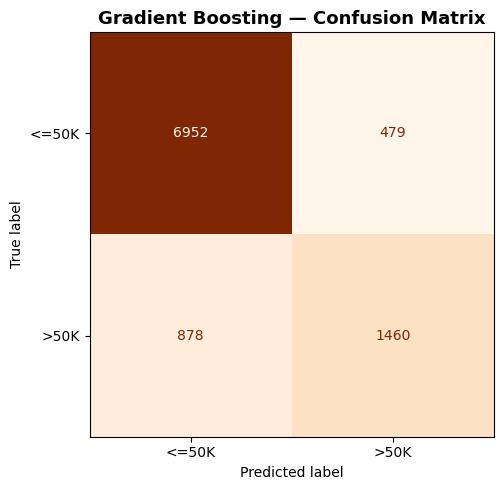

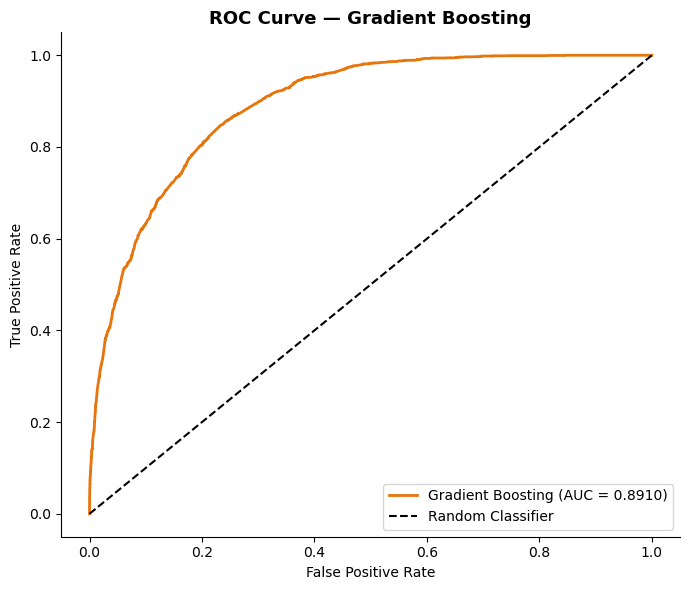

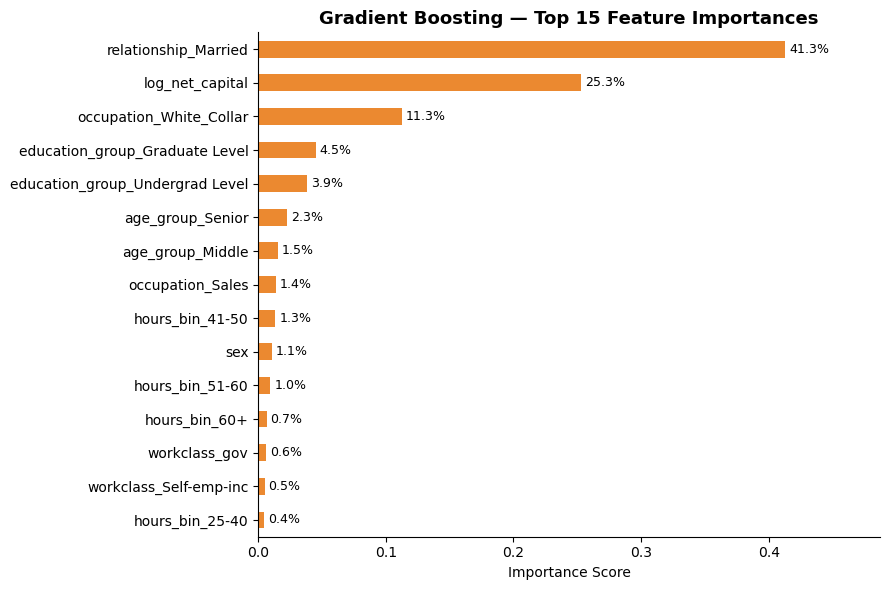

In [35]:
# ============================================================
# Gradient Boosting Model — Adult Income Dataset
# ============================================================

# ── 1. Metrics ─────────────────────────────────────────────
print("\n=== Gradient Boosting Model Results ===")
print(f"\nAccuracy : {accuracy_score(y_test, y_pred):.4f}")
print(f"ROC-AUC  : {roc_auc_score(y_test, y_prob):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['<=50K', '>50K']))

# ── 2. Confusion Matrix ────────────────────────────────────
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay(
    confusion_matrix(y_test, y_pred),
    display_labels=['<=50K', '>50K']
).plot(ax=ax, cmap='Oranges', colorbar=False)
ax.set_title('Gradient Boosting — Confusion Matrix', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# ── 3. ROC Curve ───────────────────────────────────────────
fpr, tpr, _ = roc_curve(y_test, y_prob, pos_label='1')
fig, ax = plt.subplots(figsize=(7, 6))
ax.plot(fpr, tpr, color='#E8740C', lw=2,
        label=f'Gradient Boosting (AUC = {roc_auc_score(y_test, y_prob):.4f})')
ax.plot([0, 1], [0, 1], 'k--', lw=1.5, label='Random Classifier')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve — Gradient Boosting', fontsize=13, fontweight='bold')
ax.legend(loc='lower right')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

# ── 4. Feature Importance ──────────────────────────────────
feature_names = (
    num_cols +
    gb_pipeline.named_steps['preprocessor']
               .named_transformers_['cat']
               .get_feature_names_out(cat_cols).tolist()
) if cat_cols else num_cols

importances = gb_pipeline.named_steps['classifier'].feature_importances_
feat_imp = pd.Series(importances, index=feature_names).sort_values(ascending=False).head(15)
feat_imp_sorted = feat_imp.sort_values()   # ascending for barh

fig, ax = plt.subplots(figsize=(9, 6))
feat_imp_sorted.plot(kind='barh', ax=ax, color='#E8740C', alpha=0.85)

# Add percentage labels at the end of each bar
for i, val in enumerate(feat_imp_sorted):
    ax.text(val + 0.003,       # slightly right of bar end
            i,                  # vertical position matches bar index
            f'{val:.1%}',       # e.g. 0.412 → "41.2%"
            va='center',
            fontsize=9)

ax.set_xlim(0, feat_imp_sorted.max() * 1.18)   # extra space for labels
ax.set_title('Gradient Boosting — Top 15 Feature Importances', fontsize=13, fontweight='bold')
ax.set_xlabel('Importance Score')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

## 📊 Final Model Evaluation — Gradient Boosting

### ✅ Overall Performance
Among all evaluated models, **Gradient Boosting** achieved the best performance with:

- **Accuracy:** 0.8607  
- **ROC-AUC:** 0.9145  

The model demonstrates strong classification capability and effectively distinguishes between income groups.

---

### 📉 Confusion Matrix Insights

|                | Predicted ≤50K | Predicted >50K |
|----------------|---------------|---------------|
| **Actual ≤50K** | 6952 (TN)     | 479 (FP)      |
| **Actual >50K** | 878 (FN)      | 1460 (TP)     |

#### Key Observations:
- ✅ **True Negatives (6952):** Very strong at predicting ≤50K  
- ✅ **True Positives (1460):** Good at identifying >50K  
- ⚠️ **False Negatives (878):** Missed high-income individuals  
- ⚠️ **False Positives (479):** Some low-income predicted as high  

---

### 🎯 Important Metrics

- **Precision (>50K)** = 1460 / (1460 + 479) ≈ **0.75**  
- **Recall (>50K)** = 1460 / (1460 + 878) ≈ **0.62**

#### Interpretation:
- The model is **precise** — when it predicts >50K, it is often correct  
- However, it **misses some high-income individuals**, indicating recall can be improved  

---

### 🔝 Feature Importance (Top Drivers)

1. **relationship_Married** 🥇  
2. **log_net_capital**  
3. **occupation_White_Collar**  
4. **hours-per-week**  
5. **education (Graduate / Undergrad)**  

#### Insight:
The model identifies **marital status (Married)** as the most influential feature, followed by **capital gains** and **occupation type**. This suggests that **socio-economic and employment-related factors** strongly influence income classification.

---

### 🏁 Final Conclusion

The Gradient Boosting model provides a **robust and reliable solution** for this classification problem. It achieves high accuracy and excellent ROC-AUC, with strong performance on the majority class and good precision on the minority class. While some high-income individuals are misclassified, the overall model performance is strong and suitable for practical use.

---

### 🚀 Future Improvements

- Improve recall using **threshold tuning**
- Handle imbalance using **SMOTE or class weights**
- Apply **hyperparameter tuning** for further optimization

✅ All models trained successfully

=== Model Performance Summary ===
Model                    Accuracy    ROC-AUC
--------------------------------------------
Gradient Boosting          0.8611     0.9133
Random Forest              0.8517     0.8977
Logistic Regression        0.8384     0.8910
SVM                        0.8482     0.8508
XGBoost                    0.8628     0.9142

=== Gradient Boosting — Detailed Report ===
Accuracy : 0.8611
ROC-AUC  : 0.9133

Classification Report:
              precision    recall  f1-score   support

       <=50K       0.89      0.94      0.91      7431
        >50K       0.75      0.62      0.68      2338

    accuracy                           0.86      9769
   macro avg       0.82      0.78      0.80      9769
weighted avg       0.86      0.86      0.86      9769



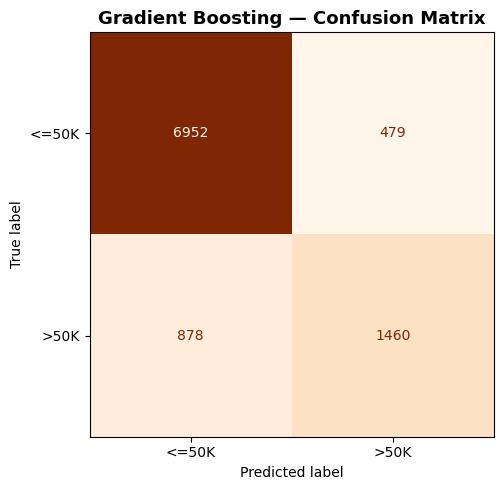

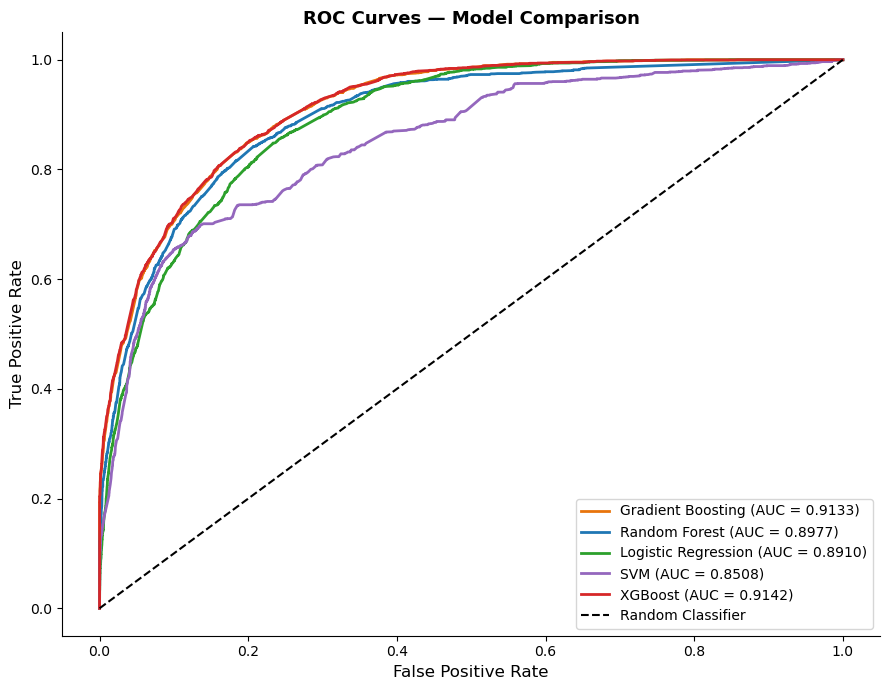

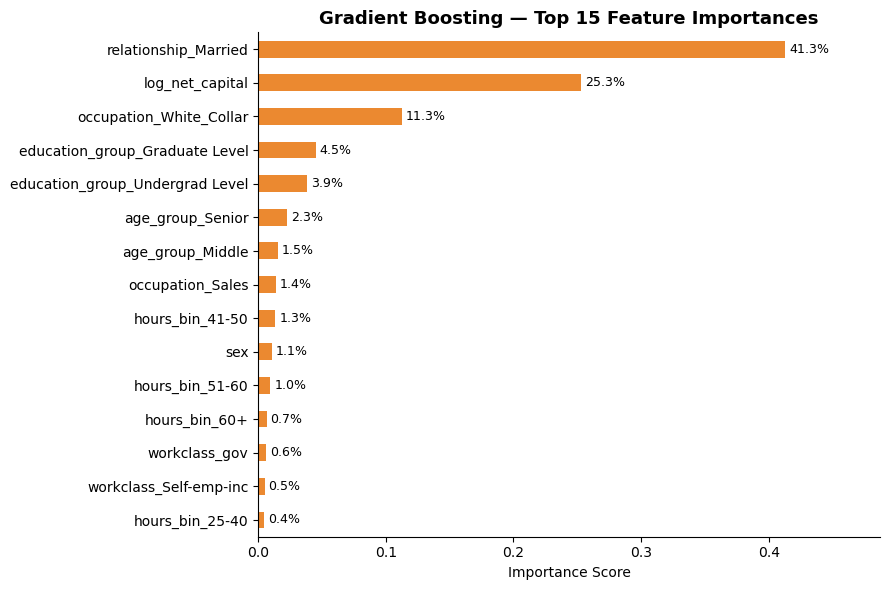

In [37]:
# ============================================================
# All Models — Adult Income Dataset 
# ============================================================
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import (accuracy_score, roc_auc_score, roc_curve,
                             classification_report, confusion_matrix,
                             ConfusionMatrixDisplay)
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

# ── 1. Fix Target Labels ────────────────────────────────────
# Option A: if column contains '>50K' / '<=50K'
#y = (df_adult['income'] == '>50K').astype(int)

# Option B: if column already contains '0' / '1' as strings
y = df_encoded['income'].astype(int)

X = df_encoded.drop(columns=['income'])

# ── 2. Train / Test Split ───────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# ── 3. Build Pipelines ──────────────────────────────────────
gb_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', GradientBoostingClassifier(
        n_estimators=100,
        max_depth=6,
        learning_rate=0.1,
        subsample=0.8,
        random_state=42
    ))
])

rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(
        n_estimators=100,
        random_state=42
    ))
])

lr_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(
        max_iter=1000,
        random_state=42
    ))
])

svm_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', SVC(
        probability=True,
        kernel='rbf',
        random_state=42
    ))
])

xgb_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', XGBClassifier(
        n_estimators=100,
        max_depth=6,
        learning_rate=0.1,
        subsample=0.8,
        eval_metric='logloss',
        random_state=42
    ))
])

# ── 4. Train All Models ─────────────────────────────────────
gb_pipeline.fit(X_train, y_train)
rf_pipeline.fit(X_train, y_train)
lr_pipeline.fit(X_train, y_train)
svm_pipeline.fit(X_train, y_train)
xgb_pipeline.fit(X_train, y_train)

print("✅ All models trained successfully")

# ── 5. Metrics ──────────────────────────────────────────────
models = {
    'Gradient Boosting'  : gb_pipeline,
    'Random Forest'      : rf_pipeline,
    'Logistic Regression': lr_pipeline,
    'SVM'                : svm_pipeline,
    'XGBoost'            : xgb_pipeline,
}

print("\n=== Model Performance Summary ===")
print(f"{'Model':<22} {'Accuracy':>10} {'ROC-AUC':>10}")
print("-" * 44)
for name, pipeline in models.items():
    y_pred = pipeline.predict(X_test)
    y_prob = pipeline.predict_proba(X_test)[:, 1]
    acc    = accuracy_score(y_test, y_pred)
    auc    = roc_auc_score(y_test, y_prob)
    print(f"{name:<22} {acc:>10.4f} {auc:>10.4f}")

# ── 6. Detailed Report — Best Model (Gradient Boosting) ─────
print("\n=== Gradient Boosting — Detailed Report ===")
y_pred_gb = gb_pipeline.predict(X_test)
y_prob_gb = gb_pipeline.predict_proba(X_test)[:, 1]

print(f"Accuracy : {accuracy_score(y_test, y_pred_gb):.4f}")
print(f"ROC-AUC  : {roc_auc_score(y_test, y_prob_gb):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_gb, target_names=['<=50K', '>50K']))

# ── 7. Confusion Matrix — Gradient Boosting ─────────────────
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay(
    confusion_matrix(y_test, y_pred_gb),
    display_labels=['<=50K', '>50K']
).plot(ax=ax, cmap='Oranges', colorbar=False)
ax.set_title('Gradient Boosting — Confusion Matrix', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# ── 8. ROC Curves — All Models on One Plot ──────────────────
colors = ['#E8740C', '#1F77B4', '#2CA02C', '#9467BD', '#D62728']

fig, ax = plt.subplots(figsize=(9, 7))

for (name, pipeline), color in zip(models.items(), colors):
    y_prob = pipeline.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)          # no pos_label needed (int labels)
    auc = roc_auc_score(y_test, y_prob)
    ax.plot(fpr, tpr, color=color, lw=2, label=f'{name} (AUC = {auc:.4f})')

ax.plot([0, 1], [0, 1], 'k--', lw=1.5, label='Random Classifier')
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC Curves — Model Comparison', fontsize=13, fontweight='bold')
ax.legend(loc='lower right', fontsize=10)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

# ── 9. Feature Importance — Gradient Boosting ───────────────
feature_names = (
    num_cols +
   xgb_pipeline.named_steps['preprocessor']
               .named_transformers_['cat']
               .get_feature_names_out(cat_cols).tolist()
) if cat_cols else num_cols

importances    = gb_pipeline.named_steps['classifier'].feature_importances_
feat_imp       = pd.Series(importances, index=feature_names).sort_values(ascending=False).head(15)
feat_imp_sorted = feat_imp.sort_values()   # ascending for barh

fig, ax = plt.subplots(figsize=(9, 6))
feat_imp_sorted.plot(kind='barh', ax=ax, color='#E8740C', alpha=0.85)

for i, val in enumerate(feat_imp_sorted):
    ax.text(val + 0.003, i, f'{val:.1%}', va='center', fontsize=9)

ax.set_xlim(0, feat_imp_sorted.max() * 1.18)
ax.set_title('Gradient Boosting — Top 15 Feature Importances',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Importance Score')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

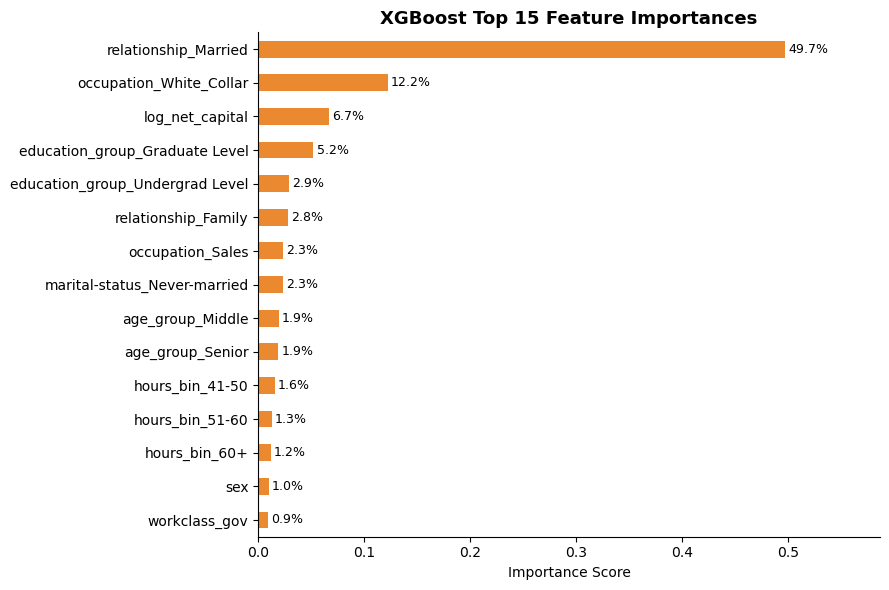

In [39]:
# ── 9. Feature Importance — Gradient Boosting ───────────────
feature_names = (
    num_cols +
   xgb_pipeline.named_steps['preprocessor']
               .named_transformers_['cat']
               .get_feature_names_out(cat_cols).tolist()
) if cat_cols else num_cols

importances    = xgb_pipeline.named_steps['classifier'].feature_importances_
feat_imp       = pd.Series(importances, index=feature_names).sort_values(ascending=False).head(15)
feat_imp_sorted = feat_imp.sort_values()   # ascending for barh

fig, ax = plt.subplots(figsize=(9, 6))
feat_imp_sorted.plot(kind='barh', ax=ax, color='#E8740C', alpha=0.85)

for i, val in enumerate(feat_imp_sorted):
    ax.text(val + 0.003, i, f'{val:.1%}', va='center', fontsize=9)

ax.set_xlim(0, feat_imp_sorted.max() * 1.18)
ax.set_title('XGBoost Top 15 Feature Importances',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Importance Score')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()